STEP 1: Loading raw data...
Train raw shape : (1040, 29)
Test raw shape  : (168, 28)

STEP 2: Fixing column mismatch...
✅ Both files have 28 columns.
   Columns: subject_id + 26 features + updrs

STEP 3: Combining train + test into one dataset...
Combined shape : (1208, 28)

STEP 4: Data quality checks...
NaN values     : 0
Duplicate rows : 1
Shape after cleaning : (1207, 28)

UPDRS sanity check (must be raw integers):
  Min : 1
  Max : 55
  Unique values : [np.int64(1), np.int64(5), np.int64(8), np.int64(11), np.int64(12), np.int64(16), np.int64(20), np.int64(23), np.int64(24), np.int64(26), np.int64(31), np.int64(32), np.int64(40), np.int64(46), np.int64(55)]

STEP 5: UPDRS severity binning...

Severity class distribution (full dataset):
  Mild       (class 1): 1077 samples (89.2%)
  Moderate   (class 2):  130 samples (10.8%)
  Severe     (class 3):    0 samples (0.0%)

 Keeping only Mild & Moderate → 1207 samples total

Class imbalance ratio: 8.3:1 (Mild:Moderate)
  Mild     : 1077


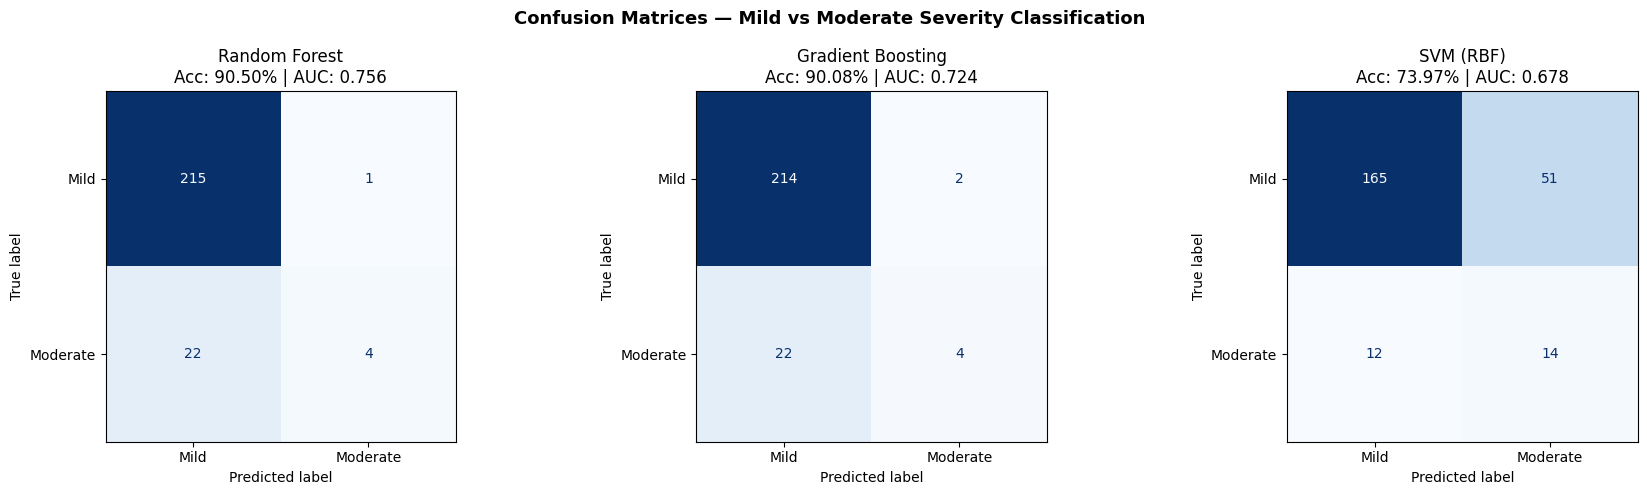

 Saved: confusion_matrices.png


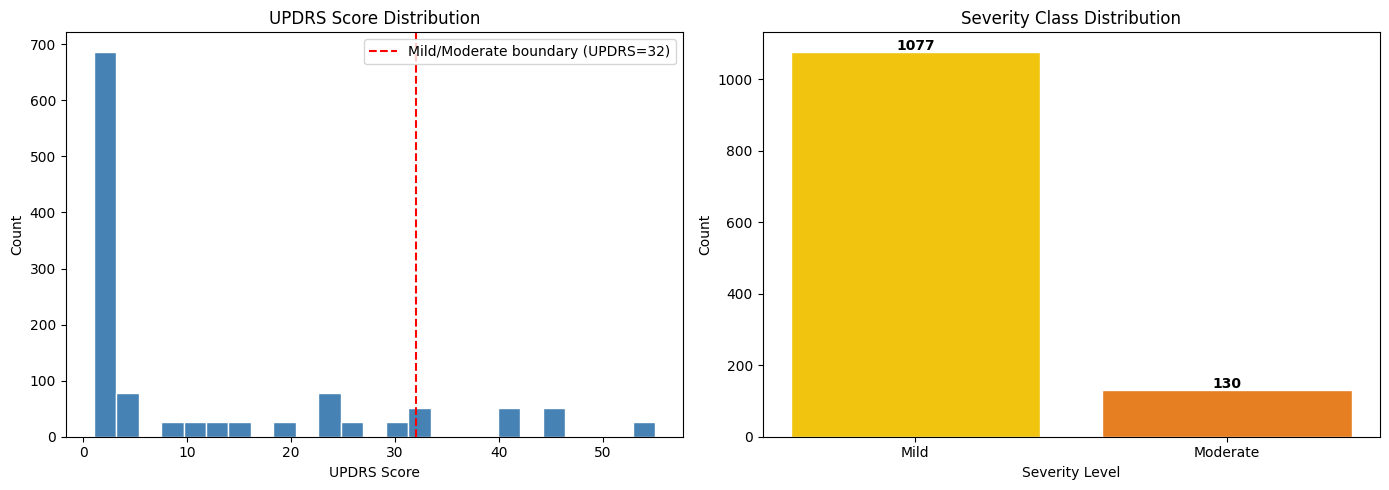

✅ Saved: severity_distribution.png


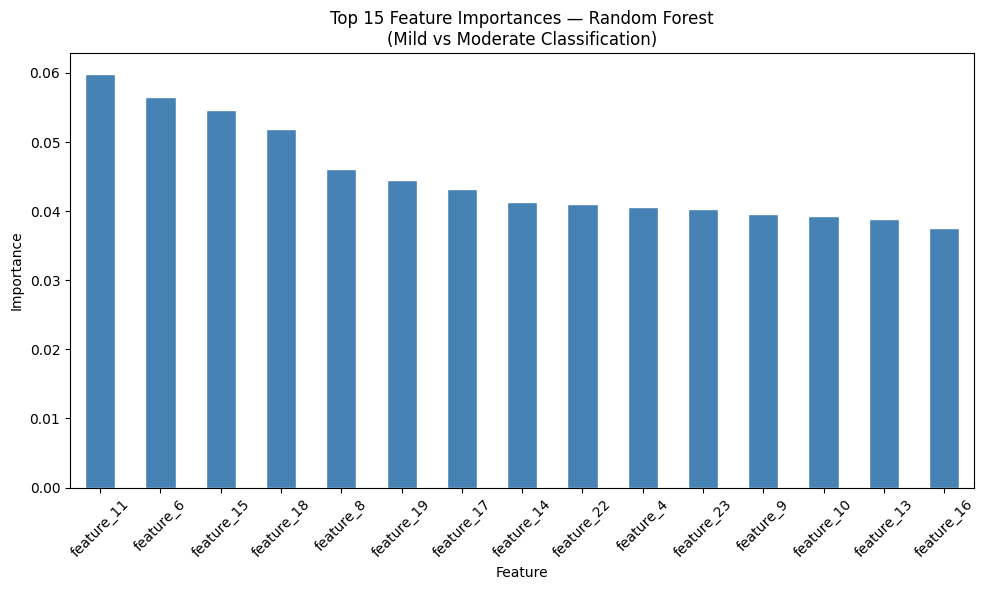

✅ Saved: feature_importance.png

FINAL SUMMARY

Task           : Mild vs Moderate Severity Classification
Total samples  : 1207
Train size     : 965 (80%)
Test size      : 242 (20%)
Features       : 26 acoustic features
Class balance  : Mild=1077, Moderate=130 (handled with class_weight)

Model                       Test Acc      AUC          CV Acc
------------------------------------------------------------
Random Forest                 90.50%   0.7561    89.84%±0.25%
Gradient Boosting             90.08%   0.7242    90.57%±0.60%
SVM (RBF)                     73.97%   0.6782    81.76%±2.30%

 Best model : Random Forest (90.50%)

 Pipeline complete!
   Output files:
     train_processed.csv       — clean scaled train data
     test_processed.csv        — clean scaled test data
     confusion_matrices.png    — model comparison
     severity_distribution.png — UPDRS & class distribution
     feature_importance.png    — top acoustic features


In [1]:
# ============================================================
# Parkinson's Disease Severity Classification
# Mild vs Moderate


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay,
                             roc_auc_score)
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings('ignore')


print("=" * 60)
print("STEP 1: Loading raw data...")
print("=" * 60)

train_df = pd.read_csv('/content/train_data.txt', header=None)
test_df  = pd.read_csv('/content/test_data.txt',  header=None)

print(f"Train raw shape : {train_df.shape}")
print(f"Test raw shape  : {test_df.shape}")


print("\n" + "=" * 60)
print("STEP 2: Fixing column mismatch...")
print("=" * 60)

feature_cols = [f'feature_{i}' for i in range(1, 27)]
col_names    = ['subject_id'] + feature_cols + ['updrs']

# Drop label col from train (col index 28)
train_df = train_df.drop(columns=[28])

assert train_df.shape[1] == test_df.shape[1] == 28, " Column mismatch!"

train_df.columns = col_names
test_df.columns  = col_names

print(f" Both files have {train_df.shape[1]} columns.")
print(f"   Columns: subject_id + 26 features + updrs")


print("\n" + "=" * 60)
print("STEP 3: Combining train + test into one dataset...")
print("=" * 60)

df = pd.concat([train_df, test_df], ignore_index=True)
print(f"Combined shape : {df.shape}")


print("\n" + "=" * 60)
print("STEP 4: Data quality checks...")
print("=" * 60)

print(f"NaN values     : {df.isna().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")

df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f"Shape after cleaning : {df.shape}")

print(f"\nUPDRS sanity check (must be raw integers):")
print(f"  Min : {df['updrs'].min()}")
print(f"  Max : {df['updrs'].max()}")
print(f"  Unique values : {sorted(df['updrs'].unique())}")


print("\n" + "=" * 60)
print("STEP 5: UPDRS severity binning...")
print("=" * 60)

def assign_severity(updrs):
    if updrs <= 32:
        return 1   # Mild
    elif updrs <= 58:
        return 2   # Moderate
    else:
        return 3   # Severe (will be flagged if present)

df['severity'] = df['updrs'].apply(assign_severity)

print("\nSeverity class distribution (full dataset):")
severity_map = {1: 'Mild', 2: 'Moderate', 3: 'Severe'}
for k, v in severity_map.items():
    count = (df['severity'] == k).sum()
    pct   = count / len(df) * 100
    print(f"  {v:10s} (class {k}): {count:4d} samples ({pct:.1f}%)")

# Keep only Mild and Moderate
df = df[df['severity'].isin([1, 2])].reset_index(drop=True)
print(f"\n Keeping only Mild & Moderate → {df.shape[0]} samples total")

# Class imbalance check
mild_count = (df['severity'] == 1).sum()
mod_count  = (df['severity'] == 2).sum()
print(f"\nClass imbalance ratio: {mild_count/mod_count:.1f}:1 (Mild:Moderate)")
print(f"  Mild     : {mild_count}")
print(f"  Moderate : {mod_count}")
print(f"  ⚠️  Imbalance will be handled with class_weight='balanced'")


print("\n" + "=" * 60)
print("STEP 6: Shuffling...")
print("=" * 60)

df = shuffle(df, random_state=42).reset_index(drop=True)
print("Severity order after shuffle (first 20):", list(df['severity'][:20]))
print(" Shuffled successfully.")


print("\n" + "=" * 60)
print("STEP 7: Stratified 80/20 split...")
print("=" * 60)

X = df[feature_cols].values
y = df['severity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"\nTrain class distribution:")
for k, v in {1: 'Mild', 2: 'Moderate'}.items():
    count = (y_train == k).sum()
    print(f"  {v:10s}: {count} ({count/len(y_train)*100:.1f}%)")
print(f"Test class distribution:")
for k, v in {1: 'Mild', 2: 'Moderate'}.items():
    count = (y_test == k).sum()
    print(f"  {v:10s}: {count} ({count/len(y_test)*100:.1f}%)")


print("\n" + "=" * 60)
print("STEP 8: Scaling features...")
print("=" * 60)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # transform test only

print(f"X_train scaled shape : {X_train_scaled.shape}")
print(f"X_test scaled shape  : {X_test_scaled.shape}")
print("Scaler fit on train only — no data leakage.")


print("\n" + "=" * 60)
print("STEP 9: Saving clean processed CSVs...")
print("=" * 60)

train_clean          = pd.DataFrame(X_train_scaled, columns=feature_cols)
train_clean['updrs'] = df.loc[train_clean.index, 'updrs'].values if len(train_clean) == len(df) else y_train
train_clean['severity'] = y_train

test_clean           = pd.DataFrame(X_test_scaled, columns=feature_cols)
test_clean['severity'] = y_test

train_clean.to_csv('train_processed.csv', index=False)
test_clean.to_csv('test_processed.csv',   index=False)
print("Saved: train_processed.csv")
print("Saved: test_processed.csv")


print("\n" + "=" * 60)
print("STEP 10: Training models...")
print("=" * 60)

target_names = ['Mild', 'Moderate']
present_classes = [1, 2]

models = {
    'Random Forest'     : RandomForestClassifier(
                            n_estimators=200,
                            class_weight='balanced',
                            random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(
                            n_estimators=200,
                            learning_rate=0.1,
                            max_depth=4,
                            random_state=42),
    'SVM (RBF)'         : SVC(
                            kernel='rbf',
                            C=10,
                            gamma='scale',
                            class_weight='balanced',
                            probability=True,
                            random_state=42),
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)

    # Cross validation on train
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                cv=cv, scoring='accuracy')

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'acc'      : acc,
        'auc'      : auc,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std()
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Test Accuracy  : {acc*100:.2f}%")
    print(f"  ROC-AUC Score  : {auc:.4f}")
    print(f"  CV Accuracy    : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
    print(f"{'='*50}")
    print(classification_report(
        y_test, y_pred,
        labels=present_classes,
        target_names=target_names,
        zero_division=0
    ))

# ============================================================
#  CONFUSION MATRICES
# ============================================================
print("\n" + "=" * 60)
print("STEP 11: Plotting confusion matrices...")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Mild vs Moderate Severity Classification',
             fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'], labels=present_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {res['acc']*100:.2f}% | AUC: {res['auc']:.3f}")

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: confusion_matrices.png")

# ============================================================
#   SEVERITY DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UPDRS distribution
axes[0].hist(df['updrs'], bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(x=32, color='red', linestyle='--', label='Mild/Moderate boundary (UPDRS=32)')
axes[0].set_title('UPDRS Score Distribution')
axes[0].set_xlabel('UPDRS Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Severity class distribution
colors = ['#f1c40f', '#e67e22']
sev_counts = df['severity'].map({1: 'Mild', 2: 'Moderate'}).value_counts()
sev_counts = sev_counts.reindex(['Mild', 'Moderate'])
axes[1].bar(sev_counts.index, sev_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Severity Class Distribution')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(sev_counts.items()):
    axes[1].text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: severity_distribution.png")

# ============================================================
# FEATURE IMPORTANCE (Random Forest)
# ============================================================
rf_model     = results['Random Forest']['model']
importances  = pd.Series(rf_model.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest\n(Mild vs Moderate Classification)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"\nTask           : Mild vs Moderate Severity Classification")
print(f"Total samples  : {len(df)}")
print(f"Train size     : {X_train_scaled.shape[0]} (80%)")
print(f"Test size      : {X_test_scaled.shape[0]} (20%)")
print(f"Features       : {X_train_scaled.shape[1]} acoustic features")
print(f"Class balance  : Mild={mild_count}, Moderate={mod_count} (handled with class_weight)")
print(f"\n{'Model':<25} {'Test Acc':>10} {'AUC':>8} {'CV Acc':>15}")
print("-" * 60)
for name, res in results.items():
    print(f"{name:<25} {res['acc']*100:>9.2f}% {res['auc']:>8.4f} {res['cv_mean']*100:>8.2f}%±{res['cv_std']*100:.2f}%")

best = max(results, key=lambda k: results[k]['acc'])
print(f"\n Best model : {best} ({results[best]['acc']*100:.2f}%)")
print("\n Pipeline complete!")
print("   Output files:")
print("     train_processed.csv       — clean scaled train data")
print("     test_processed.csv        — clean scaled test data")
print("     confusion_matrices.png    — model comparison")
print("     severity_distribution.png — UPDRS & class distribution")
print("     feature_importance.png    — top acoustic features")

STEP 1: Loading and preparing data...
Total samples  : 1207
Unique subjects: 40
Recordings/subject: 32

STEP 2: UPDRS severity binning...

After keeping Mild & Moderate only:
  Total samples : 1207
  Mild          : 1077
  Moderate      : 130
  Unique subjects: 40

STEP 3: Subject-wise split (preventing data leakage)...

Subject severity distribution:
  Mild subjects     : 35
  Moderate subjects : 5

Subject split:
  Train subjects : 32 (28 Mild, 4 Moderate)
  Test subjects  : 8 (7 Mild, 1 Moderate)

✅ No subject overlap between train and test — leakage prevented!

Recording split:
  Train recordings : 963 (Mild=859, Moderate=104)
  Test recordings  : 244 (Mild=218, Moderate=26)

STEP 4: Shuffling within splits...
✅ Shuffled train and test independently.

STEP 5: Scaling features (train only fit)...
X_train : (963, 26)
X_test  : (244, 26)
✅ Scaler fit on train subjects only.

STEP 6: Training models...

  Random Forest
  Accuracy        : 88.93%
  ROC-AUC         : 0.5141
  Moderate F1

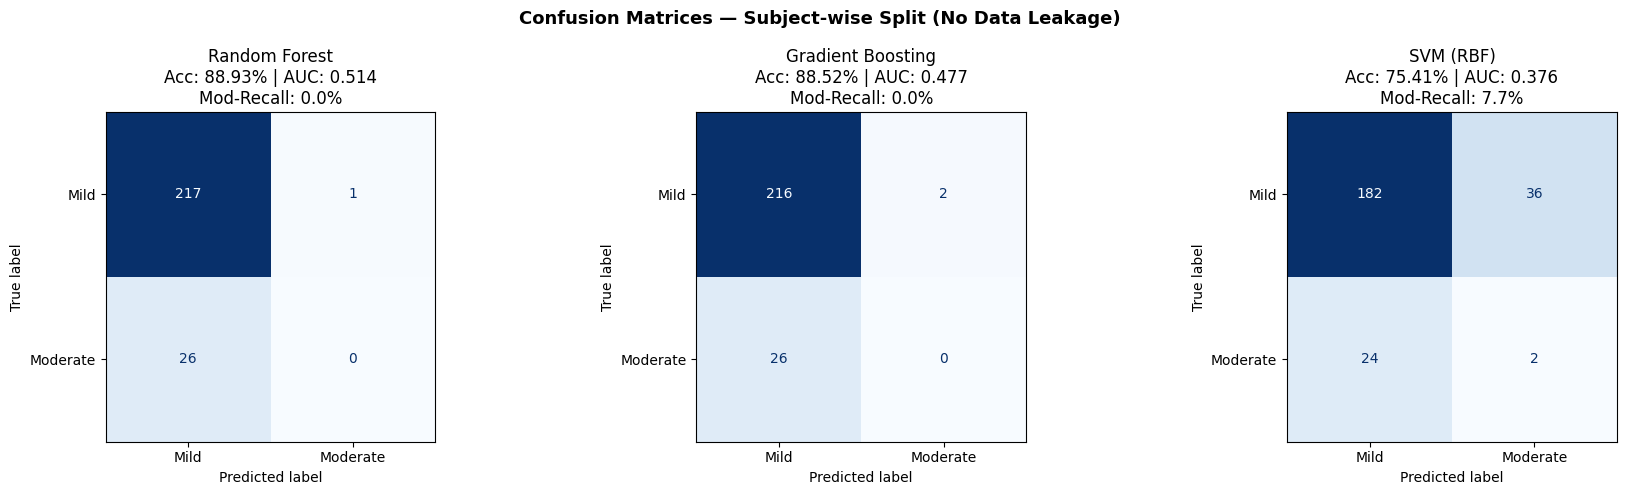

✅ Saved: confusion_matrices_subject_split.png


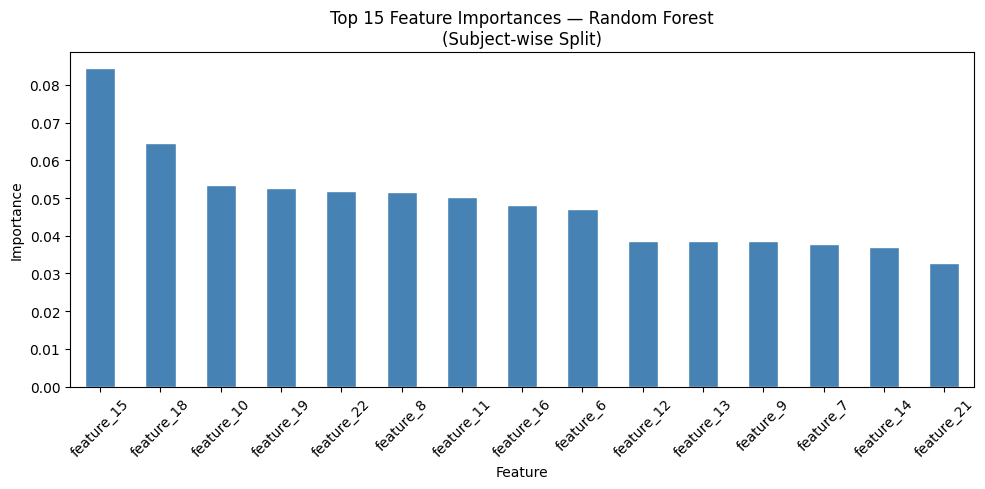

✅ Saved: feature_importance_subject_split.png

FINAL SUMMARY — Subject-wise Split

Total subjects : 40
Train subjects : 32 → 963 recordings
Test subjects  : 8  → 244 recordings
Data leakage   : ❌ None — subjects strictly separated

Model                       Accuracy      AUC   Mod-F1   Mod-Recall
-----------------------------------------------------------------
Random Forest                 88.93%   0.5141    0.000         0.0%
Gradient Boosting             88.52%   0.4769    0.000         0.0%
SVM (RBF)                     75.41%   0.3758    0.062         7.7%

🏆 Best model (by AUC): Random Forest (AUC=0.5141)

⚠️  NOTE: Accuracy may be lower than before — this is EXPECTED.
   Previous 90% was inflated due to patient memorization.
   These results reflect TRUE generalization to unseen patients.

✅ Pipeline complete!


In [ ]:
# ============================================================
# Parkinson's Disease Severity Classification
# Mild vs Moderate — Subject-wise Split (No Data Leakage)
# Dataset: UCI Parkinson Speech Dataset (Sakar et al., 2013)
# ============================================================
# KEY FIX: Subject-wise split
# Each subject has 32 recordings → random split causes leakage
# Fix: All recordings of a subject go to EITHER train OR test
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay,
                             roc_auc_score, f1_score)
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1 — LOAD & PREPARE DATA
# ============================================================
print("=" * 60)
print("STEP 1: Loading and preparing data...")
print("=" * 60)

train_raw = pd.read_csv('/content/train_data.txt', header=None)
test_raw  = pd.read_csv('',  header=None)

feature_cols = [f'feature_{i}' for i in range(1, 27)]
col_names    = ['subject_id'] + feature_cols + ['updrs']

train_raw = train_raw.drop(columns=[28])
train_raw.columns = col_names
test_raw.columns  = col_names

df = pd.concat([train_raw, test_raw], ignore_index=True)
df = df.dropna().drop_duplicates().reset_index(drop=True)

print(f"Total samples  : {len(df)}")
print(f"Unique subjects: {df['subject_id'].nunique()}")
print(f"Recordings/subject: {df['subject_id'].value_counts().values[0]}")

# ============================================================
# STEP 2 — SEVERITY BINNING
# ============================================================
print("\n" + "=" * 60)
print("STEP 2: UPDRS severity binning...")
print("=" * 60)

def assign_severity(updrs):
    if updrs <= 32:
        return 1   # Mild
    elif updrs <= 58:
        return 2   # Moderate
    else:
        return 3   # Severe

df['severity'] = df['updrs'].apply(assign_severity)
df = df[df['severity'].isin([1, 2])].reset_index(drop=True)

print(f"\nAfter keeping Mild & Moderate only:")
print(f"  Total samples : {len(df)}")
print(f"  Mild          : {(df['severity']==1).sum()}")
print(f"  Moderate      : {(df['severity']==2).sum()}")
print(f"  Unique subjects: {df['subject_id'].nunique()}")

# ============================================================
# STEP 3 — SUBJECT-WISE SPLIT
# ============================================================
# Each subject has 32 recordings
# All recordings of a subject go to EITHER train OR test
# Split subjects 80/20 → stratified by their severity label
# ============================================================
print("\n" + "=" * 60)
print("STEP 3: Subject-wise split (preventing data leakage)...")
print("=" * 60)

# Get unique subjects and their severity
# Each subject has one severity (UPDRS is consistent per subject)
subject_info = df.groupby('subject_id')['severity'].first().reset_index()
subject_info.columns = ['subject_id', 'severity']

print(f"\nSubject severity distribution:")
print(f"  Mild subjects     : {(subject_info['severity']==1).sum()}")
print(f"  Moderate subjects : {(subject_info['severity']==2).sum()}")

# Shuffle subjects
subject_info = shuffle(subject_info, random_state=42).reset_index(drop=True)

# Stratified subject split — 80% train, 20% test
mild_subjects     = subject_info[subject_info['severity']==1]['subject_id'].tolist()
moderate_subjects = subject_info[subject_info['severity']==2]['subject_id'].tolist()

# 80/20 split per class
n_mild_test     = max(1, int(len(mild_subjects) * 0.2))
n_moderate_test = max(1, int(len(moderate_subjects) * 0.2))

test_subjects  = mild_subjects[:n_mild_test] + moderate_subjects[:n_moderate_test]
train_subjects = mild_subjects[n_mild_test:] + moderate_subjects[n_moderate_test:]

print(f"\nSubject split:")
print(f"  Train subjects : {len(train_subjects)} ({len(mild_subjects)-n_mild_test} Mild, {len(moderate_subjects)-n_moderate_test} Moderate)")
print(f"  Test subjects  : {len(test_subjects)} ({n_mild_test} Mild, {n_moderate_test} Moderate)")

# Verify NO overlap
assert len(set(train_subjects) & set(test_subjects)) == 0, "❌ Subject leakage detected!"
print(f"\n✅ No subject overlap between train and test — leakage prevented!")

# Split recordings by subject
train_df = df[df['subject_id'].isin(train_subjects)].reset_index(drop=True)
test_df  = df[df['subject_id'].isin(test_subjects)].reset_index(drop=True)

print(f"\nRecording split:")
print(f"  Train recordings : {len(train_df)} (Mild={( train_df['severity']==1).sum()}, Moderate={(train_df['severity']==2).sum()})")
print(f"  Test recordings  : {len(test_df)} (Mild={(test_df['severity']==1).sum()}, Moderate={(test_df['severity']==2).sum()})")

# ============================================================
# STEP 4 — SHUFFLE WITHIN SPLITS
# ============================================================
print("\n" + "=" * 60)
print("STEP 4: Shuffling within splits...")
print("=" * 60)

train_df = shuffle(train_df, random_state=42).reset_index(drop=True)
test_df  = shuffle(test_df,  random_state=42).reset_index(drop=True)
print("✅ Shuffled train and test independently.")

# ============================================================
# STEP 5 — FEATURE/TARGET SPLIT & SCALING
# ============================================================
print("\n" + "=" * 60)
print("STEP 5: Scaling features (train only fit)...")
print("=" * 60)

X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values
y_train = train_df['severity'].values
y_test  = test_df['severity'].values

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train : {X_train_scaled.shape}")
print(f"X_test  : {X_test_scaled.shape}")
print("✅ Scaler fit on train subjects only.")

# ============================================================
# STEP 6 — TRAIN MODELS
# ============================================================
print("\n" + "=" * 60)
print("STEP 6: Training models...")
print("=" * 60)

models = {
    'Random Forest'     : RandomForestClassifier(
                            n_estimators=200,
                            class_weight='balanced',
                            random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(
                            n_estimators=200,
                            learning_rate=0.1,
                            max_depth=4,
                            random_state=42),
    'SVM (RBF)'         : SVC(
                            kernel='rbf',
                            C=10,
                            gamma='scale',
                            class_weight='balanced',
                            probability=True,
                            random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)
    f1_mod  = f1_score(y_test, y_pred, pos_label=2, zero_division=0)
    rec_mod = np.sum((y_pred==2) & (y_test==2)) / np.sum(y_test==2)

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'y_proba' : y_proba,
        'acc'     : acc,
        'auc'     : auc,
        'f1_mod'  : f1_mod,
        'rec_mod' : rec_mod
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Accuracy        : {acc*100:.2f}%")
    print(f"  ROC-AUC         : {auc:.4f}")
    print(f"  Moderate F1     : {f1_mod:.3f}")
    print(f"  Moderate Recall : {rec_mod*100:.1f}%")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                target_names=['Mild', 'Moderate'],
                                labels=[1, 2], zero_division=0))

# ============================================================
# STEP 7 — CONFUSION MATRICES
# ============================================================
print("\n" + "=" * 60)
print("STEP 7: Plotting confusion matrices...")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Subject-wise Split (No Data Leakage)',
             fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'], labels=[1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Mild', 'Moderate'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {res['acc']*100:.2f}% | AUC: {res['auc']:.3f}\n"
                 f"Mod-Recall: {res['rec_mod']*100:.1f}%")

plt.tight_layout()
plt.savefig('confusion_matrices_subject_split.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: confusion_matrices_subject_split.png")

# ============================================================
# STEP 8 — FEATURE IMPORTANCE
# ============================================================
rf_model     = results['Random Forest']['model']
importances  = pd.Series(rf_model.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
top_features.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest\n(Subject-wise Split)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance_subject_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance_subject_split.png")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("FINAL SUMMARY — Subject-wise Split")
print("=" * 60)
print(f"\nTotal subjects : {df['subject_id'].nunique()}")
print(f"Train subjects : {len(train_subjects)} → {len(train_df)} recordings")
print(f"Test subjects  : {len(test_subjects)}  → {len(test_df)} recordings")
print(f"Data leakage   : ❌ None — subjects strictly separated")
print(f"\n{'Model':<25} {'Accuracy':>10} {'AUC':>8} {'Mod-F1':>8} {'Mod-Recall':>12}")
print("-" * 65)
for name, res in results.items():
    print(f"{name:<25} {res['acc']*100:>9.2f}% {res['auc']:>8.4f} "
          f"{res['f1_mod']:>8.3f} {res['rec_mod']*100:>11.1f}%")

best = max(results, key=lambda k: results[k]['auc'])
print(f"\n🏆 Best model (by AUC): {best} (AUC={results[best]['auc']:.4f})")
print("\n⚠️  NOTE: Accuracy may be lower than before — this is EXPECTED.")
print("   Previous 90% was inflated due to patient memorization.")
print("   These results reflect TRUE generalization to unseen patients.")
print("\n Pipeline complete!")